In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

import warnings
warnings.filterwarnings("ignore")

In [48]:
df = pd.read_csv("pulsar_stars.csv")

df.head()

,Mean of the integrated profile,Standard deviation of the integrated profile,Excess kurtosis of the integrated profile,Skewness of the integrated profile,Mean of the DM-SNR curve,Standard deviation of the DM-SNR curve,Excess kurtosis of the DM-SNR curve,Skewness of the DM-SNR curve,target_class
0,140.562500,55.683782,-0.234571,-0.699648,3.199833,19.110426,7.975532,74.242225,0
1,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580,0
2,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909,0
3,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661,0
4,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306,0


In [49]:
df = pd.read_csv("pulsar_stars.csv")
df.head()

,Mean of the integrated profile,Standard deviation of the integrated profile,Excess kurtosis of the integrated profile,Skewness of the integrated profile,Mean of the DM-SNR curve,Standard deviation of the DM-SNR curve,Excess kurtosis of the DM-SNR curve,Skewness of the DM-SNR curve,target_class
0,140.562500,55.683782,-0.234571,-0.699648,3.199833,19.110426,7.975532,74.242225,0
1,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580,0
2,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909,0
3,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661,0
4,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306,0


In [51]:
print("Dataset shape:", df.shape)

Dataset shape: (17898, 9)


In [52]:
print(df.columns)

Index([' Mean of the integrated profile',
       ' Standard deviation of the integrated profile',
       ' Excess kurtosis of the integrated profile',
       ' Skewness of the integrated profile', ' Mean of the DM-SNR curve',
       ' Standard deviation of the DM-SNR curve',
       ' Excess kurtosis of the DM-SNR curve', ' Skewness of the DM-SNR curve',
       'target_class'],
      dtype='str')


In [53]:
df.columns = df.columns.str.strip()

print(df.columns)

Index(['Mean of the integrated profile',
       'Standard deviation of the integrated profile',
       'Excess kurtosis of the integrated profile',
       'Skewness of the integrated profile', 'Mean of the DM-SNR curve',
       'Standard deviation of the DM-SNR curve',
       'Excess kurtosis of the DM-SNR curve', 'Skewness of the DM-SNR curve',
       'target_class'],
      dtype='str')


In [16]:
df.columns = df.columns.str.strip()

In [17]:
df.columns

Index(['Mean of the integrated profile',
       'Standard deviation of the integrated profile',
       'Excess kurtosis of the integrated profile',
       'Skewness of the integrated profile', 'Mean of the DM-SNR curve',
       'Standard deviation of the DM-SNR curve',
       'Excess kurtosis of the DM-SNR curve', 'Skewness of the DM-SNR curve',
       'target_class'],
      dtype='str')

In [54]:
df.columns = [
    "IP Mean",
    "IP Sd",
    "IP Kurtosis",
    "IP Skewness",
    "DM-SNR Mean",
    "DM-SNR Sd",
    "DM-SNR Kurtosis",
    "DM-SNR Skewness",
    "target_class"
]

df.head()

,IP Mean,IP Sd,IP Kurtosis,IP Skewness,DM-SNR Mean,DM-SNR Sd,DM-SNR Kurtosis,DM-SNR Skewness,target_class
0,140.562500,55.683782,-0.234571,-0.699648,3.199833,19.110426,7.975532,74.242225,0
1,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580,0
2,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909,0
3,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661,0
4,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306,0


In [55]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17898 entries, 0 to 17897
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   IP Mean          17898 non-null  float64
 1   IP Sd            17898 non-null  float64
 2   IP Kurtosis      17898 non-null  float64
 3   IP Skewness      17898 non-null  float64
 4   DM-SNR Mean      17898 non-null  float64
 5   DM-SNR Sd        17898 non-null  float64
 6   DM-SNR Kurtosis  17898 non-null  float64
 7   DM-SNR Skewness  17898 non-null  float64
 8   target_class     17898 non-null  int64  
dtypes: float64(8), int64(1)
memory usage: 1.2 MB


In [56]:
print(df.isnull().sum())

IP Mean            0
IP Sd              0
IP Kurtosis        0
IP Skewness        0
DM-SNR Mean        0
DM-SNR Sd          0
DM-SNR Kurtosis    0
DM-SNR Skewness    0
target_class       0
dtype: int64


In [57]:
print(df["target_class"].value_counts())

target_class
0    16259
1     1639
Name: count, dtype: int64


In [58]:
print(
    df["target_class"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

target_class
0    90.84
1     9.16
Name: proportion, dtype: float64


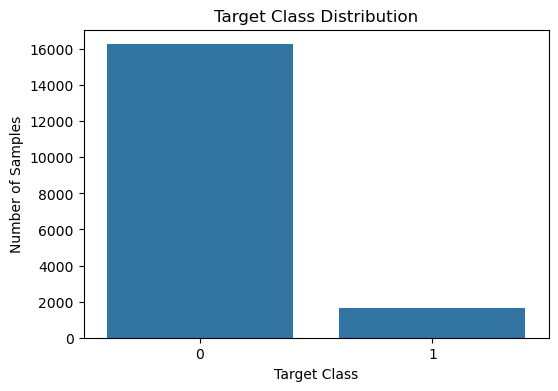

In [59]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="target_class")

plt.title("Target Class Distribution")
plt.xlabel("Target Class")
plt.ylabel("Number of Samples")
plt.show()

In [60]:
df.describe()

,IP Mean,IP Sd,IP Kurtosis,IP Skewness,DM-SNR Mean,DM-SNR Sd,DM-SNR Kurtosis,DM-SNR Skewness,target_class
count,17898.000000,17898.000000,17898.000000,17898.000000,17898.000000,17898.000000,17898.000000,17898.000000,17898.000000
mean,111.079968,46.549532,0.477857,1.770279,12.614400,26.326515,8.303556,104.857709,0.091574
std,25.652935,6.843189,1.064040,6.167913,29.472897,19.470572,4.506092,106.514540,0.288432
min,5.812500,24.772042,-1.876011,-1.791886,0.213211,7.370432,-3.139270,-1.976976,0.000000
25%,100.929688,42.376018,0.027098,-0.188572,1.923077,14.437332,5.781506,34.960504,0.000000
50%,115.078125,46.947479,0.223240,0.198710,2.801839,18.461316,8.433515,83.064556,0.000000
75%,127.085938,51.023202,0.473325,0.927783,5.464256,28.428104,10.702959,139.309330,0.000000
max,192.617188,98.778911,8.069522,68.101622,223.392141,110.642211,34.539844,1191.000837,1.000000


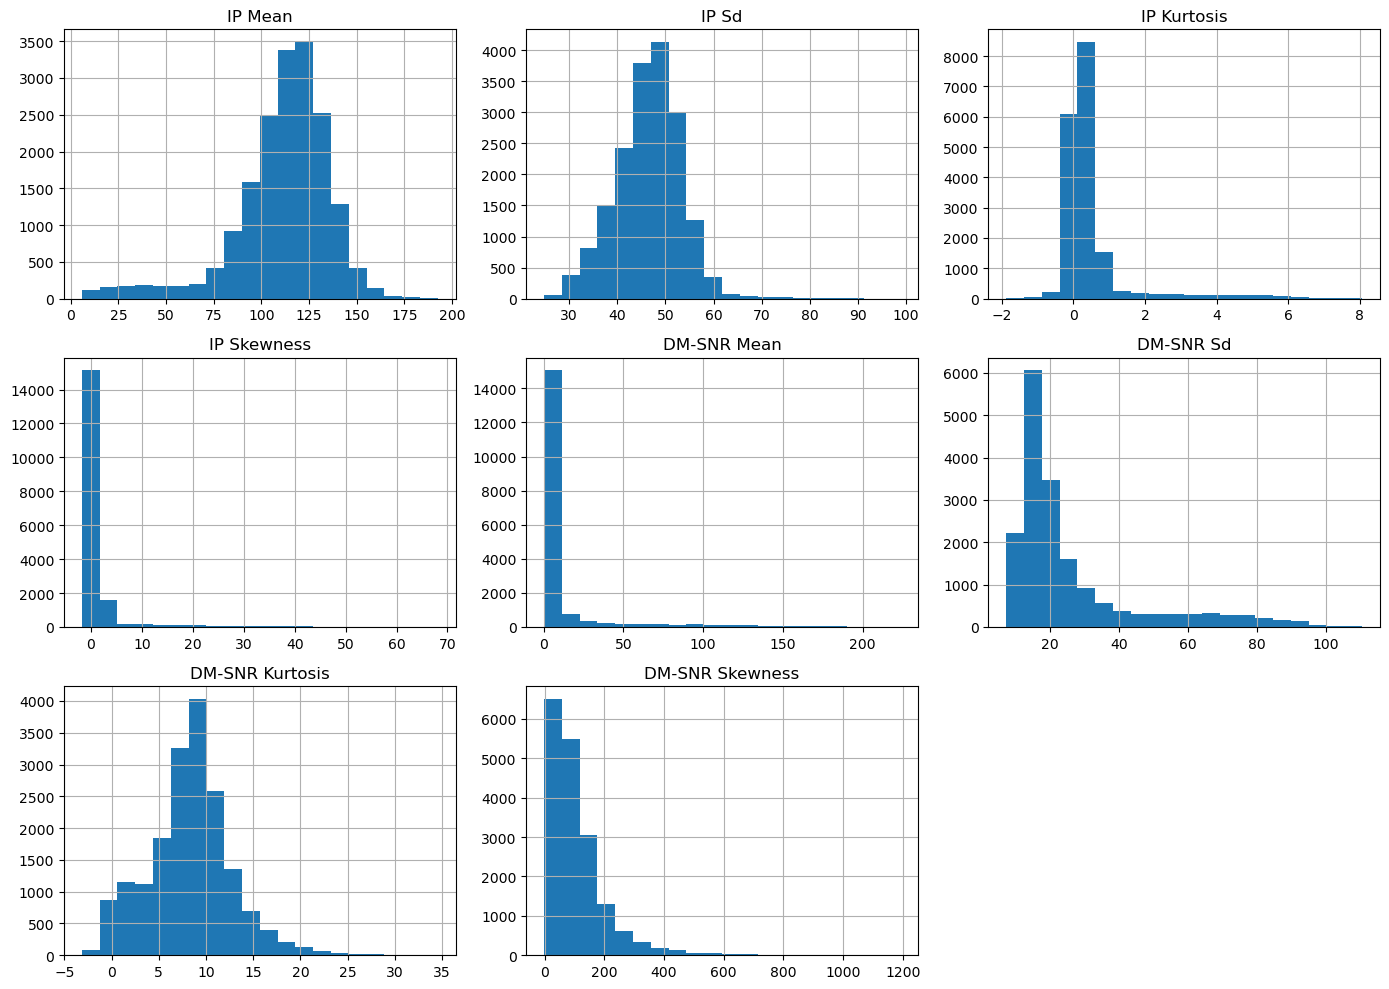

In [61]:
features = [
    "IP Mean",
    "IP Sd",
    "IP Kurtosis",
    "IP Skewness",
    "DM-SNR Mean",
    "DM-SNR Sd",
    "DM-SNR Kurtosis",
    "DM-SNR Skewness"
]

df[features].hist(
    bins=20,
    figsize=(14, 10)
)

plt.tight_layout()
plt.show()

In [62]:
X = df.drop(columns=["target_class"])
y = df["target_class"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (17898, 8)
y shape: (17898,)


In [63]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (14318, 8)
X_test : (3580, 8)
y_train: (14318,)
y_test : (3580,)


In [66]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [70]:
from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Scale training data
X_train = scaler.fit_transform(X_train)

# Scale test data
X_test = scaler.transform(X_test)

In [71]:
from sklearn.svm import SVC

model = SVC(kernel="rbf", C=1.0, gamma="scale")

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [72]:
scaler.fit_transform(X_train)

array([[-2.67946778, -1.79478007,  2.8595421 , ...,  2.34299093,
        -1.70589651, -0.99075829],
       [ 0.18953379, -0.66026852, -0.27355262, ..., -0.47731643,
         0.26237997, -0.03944414],
       [ 0.68546338,  0.30925141, -0.51573674, ..., -0.49890602,
         0.31301109,  0.08889377],
       ...,
       [ 0.14952961, -0.24472617, -0.03814834, ..., -0.54289561,
         0.34029374,  0.16147868],
       [-0.41541481, -0.04221465, -0.0753563 , ..., -0.44293414,
         0.19543697, -0.0560525 ],
       [-1.19687038,  0.23875892,  1.06154722, ...,  2.02475585,
        -1.43672236, -0.96586768]], shape=(14318, 8))

In [73]:
scaler.transform(X_test)

array([[ 9.65187219e-01, -3.35364668e-01, -4.67568409e-01, ...,
        -6.45113282e-01,  2.45541889e-01,  1.69103520e-01],
       [-3.34184967e-01,  1.81735666e+00, -1.19826621e-02, ...,
        -5.86590535e-01,  4.98551700e-01,  2.05850076e-01],
       [ 3.48023603e-01, -9.48250544e-02, -2.57369242e-01, ...,
        -7.73218534e-01,  1.38186908e+00,  1.43677737e+00],
       ...,
       [ 4.43911468e-01,  2.08747018e+00, -3.98871353e-01, ...,
         1.69311261e-01, -4.50598504e-01, -6.05155825e-01],
       [ 1.98389673e-01,  3.91910528e-01, -1.99692106e-01, ...,
        -9.29968586e-01,  4.03402471e+00,  6.36743991e+00],
       [-4.25797577e-01,  2.59619294e-01,  7.88728889e-02, ...,
        -5.38923805e-01,  2.85665643e-01,  1.69964000e-03]],
      shape=(3580, 8))

In [76]:
svm_model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    random_state=42
)

In [77]:
svm_model.fit(X_train_scaled, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [78]:
y_pred = svm_model.predict(X_test_scaled)

print(y_pred[:20])

[0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 1 0]


In [79]:
accuracy = accuracy_score(y_test, y_pred)

print("SVM Accuracy:", accuracy)
print("SVM Accuracy (%):", accuracy * 100)

SVM Accuracy: 0.9807262569832402
SVM Accuracy (%): 98.07262569832402


In [81]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[3226   26]
 [  49  279]]


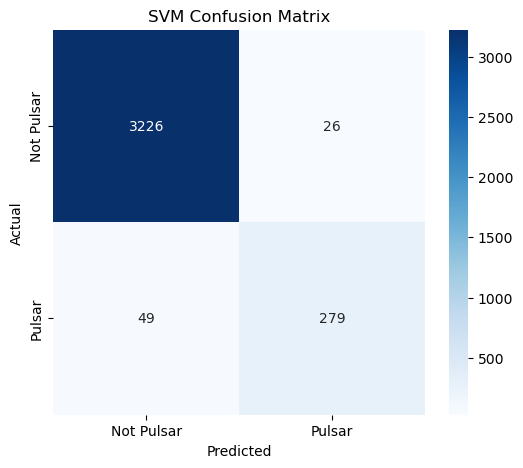

In [82]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Pulsar", "Pulsar"],
    yticklabels=["Not Pulsar", "Pulsar"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")

plt.show()

In [83]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3252
           1       0.91      0.85      0.88       328

    accuracy                           0.98      3580
   macro avg       0.95      0.92      0.94      3580
weighted avg       0.98      0.98      0.98      3580



In [84]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Precision :", precision)
print("Recall    :", recall)
print("F1 Score  :", f1)

Precision : 0.9147540983606557
Recall    : 0.850609756097561
F1 Score  : 0.8815165876777251


In [85]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

results.head(20)

,Actual,Predicted
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
5,0,0
6,0,0
7,0,0
8,1,1
9,0,0


In [86]:
linear_svm = SVC(
    kernel="linear",
    C=1.0
)

linear_svm.fit(X_train_scaled, y_train)

linear_pred = linear_svm.predict(X_test_scaled)

print(
    "Linear SVM Accuracy:",
    accuracy_score(y_test, linear_pred)
)

Linear SVM Accuracy: 0.9798882681564246


In [88]:
rbf_svm = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale"
)

rbf_svm.fit(X_train_scaled, y_train)

rbf_pred = rbf_svm.predict(X_test_scaled)

print(
    "RBF SVM Accuracy:",
    accuracy_score(y_test, rbf_pred)
)

RBF SVM Accuracy: 0.9807262569832402


In [ ]:
poly_svm = SVC(
    kernel="poly",
    C=1.0,
    degree=3
)

poly_svm.fit(X_train_scaled, y_train)

poly_pred = poly_svm.predict(X_test_scaled)

print(
    "Polynomial SVM Accuracy:",
    accuracy_score(y_test, poly_pred)
)